In [ ]:
import json, requests, gzip, re, os
import pandas as pd
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

OUT_DIR = Path("../data/gdc_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("data/tcga_cna")   # 🔥 changed
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("data/tcga_cna")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_WORKERS = 8

CANCERS = ["TCGA-BRCA", "TCGA-LUAD", "TCGA-LUSC", "TCGA-HNSC"]
CANCERS = [
    'TCGA-BLCA', 'TCGA-BRCA', 'TCGA-CESC', 'TCGA-COAD',
    'TCGA-ESCA', 'TCGA-GBM', 'TCGA-HNSC', 'TCGA-KIRC',
    'TCGA-KIRP', 'TCGA-LAML', 'TCGA-LGG', 'TCGA-LIHC',
    'TCGA-LUAD', 'TCGA-LUSC', 'TCGA-OV', 'TCGA-PAAD',
    'TCGA-PCPG', 'TCGA-PRAD', 'TCGA-READ', 'TCGA-SARC',
    'TCGA-SKCM', 'TCGA-STAD', 'TCGA-THCA', 'TCGA-UCEC'
    ]

GDC_API_FILES = "https://api.gdc.cancer.gov/files"
GDC_API_DATA = "https://api.gdc.cancer.gov/data"

def get_cna_file_ids(project):
    cache_file = OUT_DIR / f"{project}_cna_files.json"

    if cache_file.exists():
        print(f"[cache] CNA file IDs: {project}")
        with open(cache_file) as f:
            return json.load(f)

    print(f"[download] CNA file IDs: {project}")

    params = {
        "filters": {
            "op": "and",
            "content": [
                {"op": "in", "content": {"field": "cases.project.project_id", "value": [project]}},
                {"op": "in", "content": {"field": "data_type", "value": ["Copy Number Segment"]}}
            ]
        },
        "fields": "file_id,file_name",
        "format": "JSON",
        "size": 200
    }

    r = requests.post(GDC_API_FILES, json=params)
    r.raise_for_status()
    hits = r.json()["data"]["hits"]

    file_ids = [(f["file_id"], f["file_name"]) for f in hits]

    with open(cache_file, "w") as f:
        json.dump(file_ids, f)

    return file_ids

def download_one(file_id, file_name, project_dir):
    file_path = project_dir / file_name

    if file_path.exists():
        return

    url = f"{GDC_API_DATA}/{file_id}"

    try:
        r = requests.get(url, stream=True, timeout=60)
        if r.status_code != 200:
            return

        with open(file_path, "wb") as f:
            for chunk in r.iter_content(8192):
                if chunk:
                    f.write(chunk)
    except:
        pass

def download_cna_files(file_ids, project):
    project_dir = DATA_DIR / project
    project_dir.mkdir(parents=True, exist_ok=True)

    with ThreadPoolExecutor(MAX_WORKERS) as ex:
        futures = [
            ex.submit(download_one, fid, fname, project_dir)
            for fid, fname in file_ids
        ]

        for _ in tqdm(as_completed(futures), total=len(futures), desc=f"Downloading CNA {project}"):
            pass

def load_cna_matrix(project, gene_annot, gene_list=None):
    cancer_dir = DATA_DIR / project

    gene_sample = defaultdict(dict)
    all_samples = set()

    for seg_file in cancer_dir.rglob("*.seg*"):
        try:
            df = pd.read_csv(seg_file, sep="\t")

            if not {"Chromosome", "Start", "End", "Segment_Mean"}.issubset(df.columns):
                continue

            sample = seg_file.name.split(".")[0]
            all_samples.add(sample)

            for _, row in df.iterrows():
                chrom = str(row["Chromosome"])
                start = int(row["Start"])
                end = int(row["End"])
                val = float(row["Segment_Mean"])

                # map segments → genes
                for g, (g_chr, g_start, g_end) in gene_annot.items():
                    if chrom == g_chr and not (end < g_start or start > g_end):
                        gene_sample[g][sample] = val

        except Exception as e:
            print(f"[WARN] CNA load failed {seg_file}: {e}")
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    mat = pd.DataFrame(0.0, index=genes, columns=samples)

    for g, sdict in gene_sample.items():
        for s, v in sdict.items():
            mat.at[g, s] = v

    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat

def load_cna_matrix_cached(cancer, gene_annot, gene_list):
    cache_file = OUT_DIR / f"{cancer}_cna_matrix.pkl"

    if cache_file.exists():
        print(f"[cache] CNA matrix: {cancer}")
        return pd.read_pickle(cache_file)

    print(f"[build] CNA matrix: {cancer}")
    mat = load_cna_matrix(cancer, gene_annot, gene_list)

    mat.to_pickle(cache_file)
    return mat

def get_latest_gencode_url():
    base = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/"

    r = requests.get(base)
    r.raise_for_status()

    versions = re.findall(r"release_(\d+)", r.text)
    latest = max(map(int, versions))

    url = f"{base}/release_{latest}/gencode.v{latest}.annotation.gtf.gz"

    print(f"[INFO] Latest GENCODE: v{latest}")
    return url, f"v{latest}"


GENCODE_URL, GENCODE_VERSION = get_latest_gencode_url()
GTF_PATH = OUT_DIR / f"gencode.{GENCODE_VERSION}.annotation.gtf.gz"

def download_gtf():
    if GTF_PATH.exists() and GTF_PATH.stat().st_size > 1e6:
        print("[cache] GTF")
        return GTF_PATH

    print("[download] GTF")
    r = requests.get(GENCODE_URL, stream=True)
    r.raise_for_status()

    with open(GTF_PATH, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)

    return GTF_PATH

def parse_gtf():
    path = download_gtf()

    gene_map = {}
    gene_annot = {}

    with gzip.open(path, "rt") as f:
        for line in tqdm(f, desc="Parsing GTF"):
            if line.startswith("#"):
                continue

            parts = line.split("\t")
            if parts[2] != "gene":
                continue

            chrom = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            attr = parts[8]

            gid = re.search(r'gene_id "([^"]+)"', attr)
            gname = re.search(r'gene_name "([^"]+)"', attr)
            gtype = re.search(r'gene_type "([^"]+)"', attr)

            if not gid or not gname or not gtype:
                continue

            gid = gid.group(1).split(".")[0]
            gname = gname.group(1)
            gtype = gtype.group(1)

            if gtype != "protein_coding":
                continue

            gene_map[gid] = gname
            gene_annot[gname] = (chrom, start, end)

    gene_list = sorted(gene_annot.keys())

    print(f"[INFO] {len(gene_list)} genes loaded")
    return gene_list, gene_map, gene_annot


[INFO] Latest GENCODE: v49


In [3]:
def load_cna_matrix(project, gene_annot, gene_list=None):
    cancer_dir = OUT_DIR / project / "cna"

    gene_sample = defaultdict(dict)
    all_samples = set()

    for seg_file in cancer_dir.rglob("*.seg*"):
        try:
            df = pd.read_csv(seg_file, sep="\t")

            # Expected columns
            if not {"Chromosome", "Start", "End", "Segment_Mean"}.issubset(df.columns):
                continue

            sample = seg_file.name.split(".")[0]
            all_samples.add(sample)

            for _, row in df.iterrows():
                chrom = str(row["Chromosome"])
                start = int(row["Start"])
                end = int(row["End"])
                val = float(row["Segment_Mean"])

                # map segment → genes
                for g, (g_chr, g_start, g_end) in gene_annot.items():
                    if chrom == g_chr and not (end < g_start or start > g_end):
                        gene_sample[g][sample] = val

        except Exception as e:
            print(f"[WARN] CNA load failed {seg_file}: {e}")
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    mat = pd.DataFrame(0.0, index=genes, columns=samples)

    for g, sdict in gene_sample.items():
        for s, v in sdict.items():
            mat.at[g, s] = v

    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat

In [4]:

def plot_top_genes_combined(expr_df, cancer, top_n=15):
    score = expr_df["logFC"] * -np.log10(expr_df["fdr"] + 1e-10)

    expr_df = expr_df.copy()
    expr_df["score"] = score

    top_genes = expr_df.reindex(
        expr_df["score"].abs().sort_values(ascending=False).head(top_n).index
    )

    plt.figure(figsize=(10, 8))
    plt.barh(top_genes.index, top_genes["score"])
    plt.title(f"{cancer} - Most Dysregulated Genes")
    plt.xlabel("Signed significance score")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

def plot_top_genes_logfc(expr_df, cancer, top_n=15):
    top_up = expr_df.sort_values("logFC", ascending=False).head(top_n)
    top_down = expr_df.sort_values("logFC", ascending=True).head(top_n)

    plt.figure(figsize=(10, 8))

    plt.barh(top_up.index, top_up["logFC"])
    plt.title(f"{cancer} - Top Upregulated Genes")
    plt.xlabel("logFC")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.barh(top_down.index, top_down["logFC"])
    plt.title(f"{cancer} - Top Downregulated Genes")
    plt.xlabel("logFC")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

def plot_volcano(expr_df, cancer):
    logFC = expr_df["logFC"]
    neglogp = -np.log10(expr_df["pval"] + 1e-10)

    plt.figure(figsize=(8, 6))
    plt.scatter(logFC, neglogp, s=10)

    plt.title(f"{cancer} Volcano Plot")
    plt.xlabel("logFC")
    plt.ylabel("-log10(p-value)")

    plt.axhline(-np.log10(0.05), linestyle="--")
    plt.axvline(1, linestyle="--")
    plt.axvline(-1, linestyle="--")

    plt.show()


def plot_heatmap_zscore(GE_all, top_n=50):
    mat = GE_all.copy()

    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    # z-score per gene
    mat = (mat - mat.mean(axis=1).values[:, None]) / (mat.std(axis=1).values[:, None] + 1e-8)

    plt.figure(figsize=(12, 10))
    plt.imshow(mat.values, aspect="auto")

    plt.colorbar(label="Z-score")

    plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
    plt.yticks(range(len(mat.index)), mat.index)

    plt.title("Z-score Heatmap Across Cancers")
    plt.xlabel("Cancer")
    plt.ylabel("Gene")

    plt.tight_layout()
    plt.show()


def plot_clustered_heatmap(GE_all, top_n=50):
    mat = GE_all.copy()

    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    sns.clustermap(
        mat,
        figsize=(12, 10),
        cmap="viridis",
        standard_scale=0
    )

def plot_heatmap(GE_all, top_n=50):
    mat = GE_all.copy()

    # select most variable genes (more informative)
    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    plt.figure(figsize=(12, 10))
    plt.imshow(mat.values, aspect="auto")

    plt.colorbar(label="Expression score")

    plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
    plt.yticks(range(len(mat.index)), mat.index)

    plt.title("Top Variable Genes Across Cancers")
    plt.xlabel("Cancer")
    plt.ylabel("Gene")

    plt.tight_layout()
    plt.show()


[cache] GTF


Parsing GTF: 7750159it [00:12, 610394.14it/s]


[INFO] 20070 genes loaded

=== TCGA-BRCA ===
[build] CNA matrix: TCGA-BRCA
[compute] CNA scores: TCGA-BRCA
[DEBUG] CNA matrix: (20070, 30)
[DEBUG] After filtering: (20045, 30)


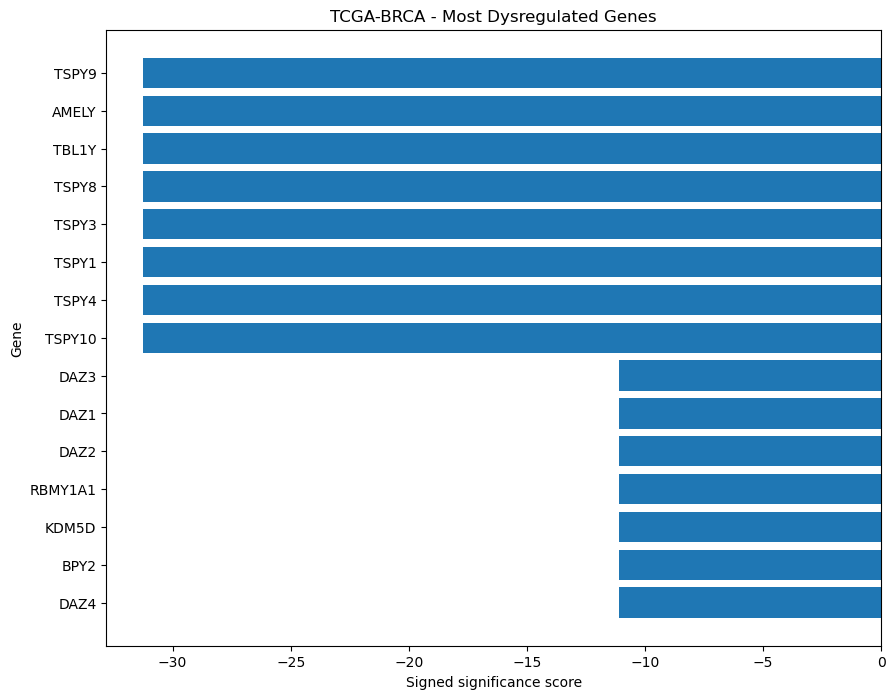

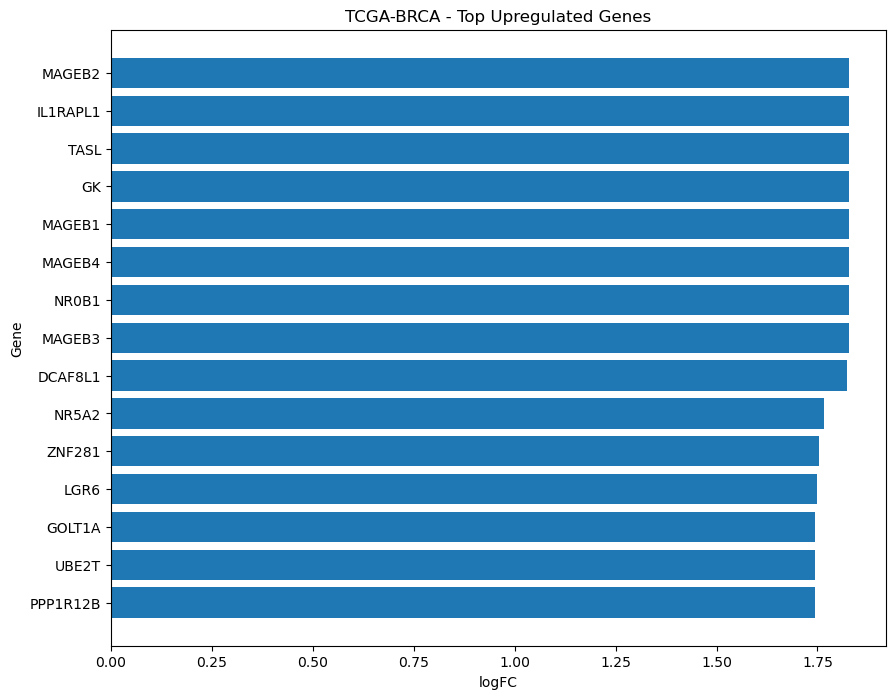

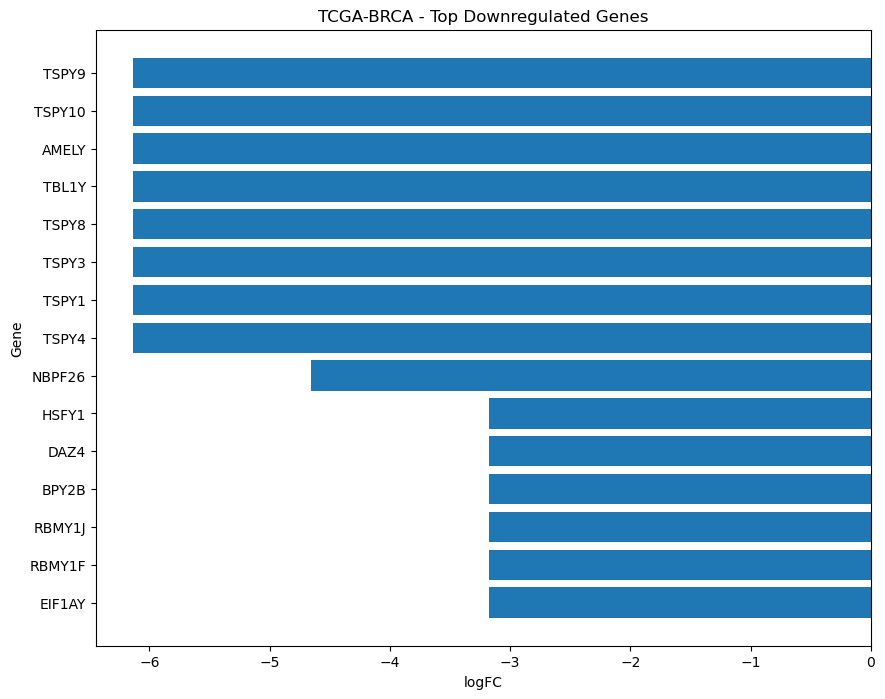


=== TCGA-LUAD ===
[build] CNA matrix: TCGA-LUAD
[compute] CNA scores: TCGA-LUAD
[DEBUG] CNA matrix: (20070, 30)
[DEBUG] After filtering: (20045, 30)


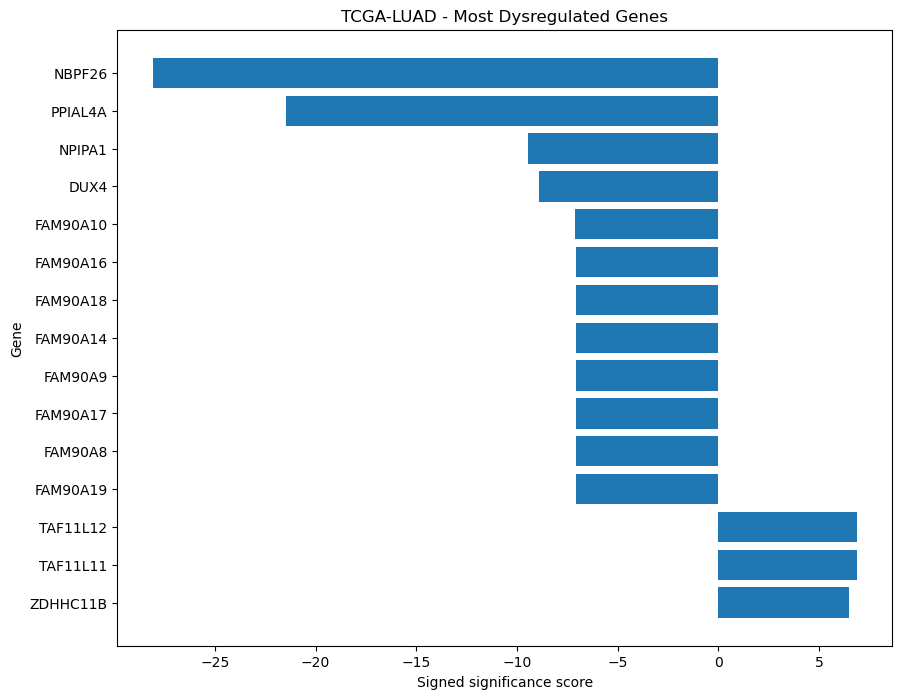

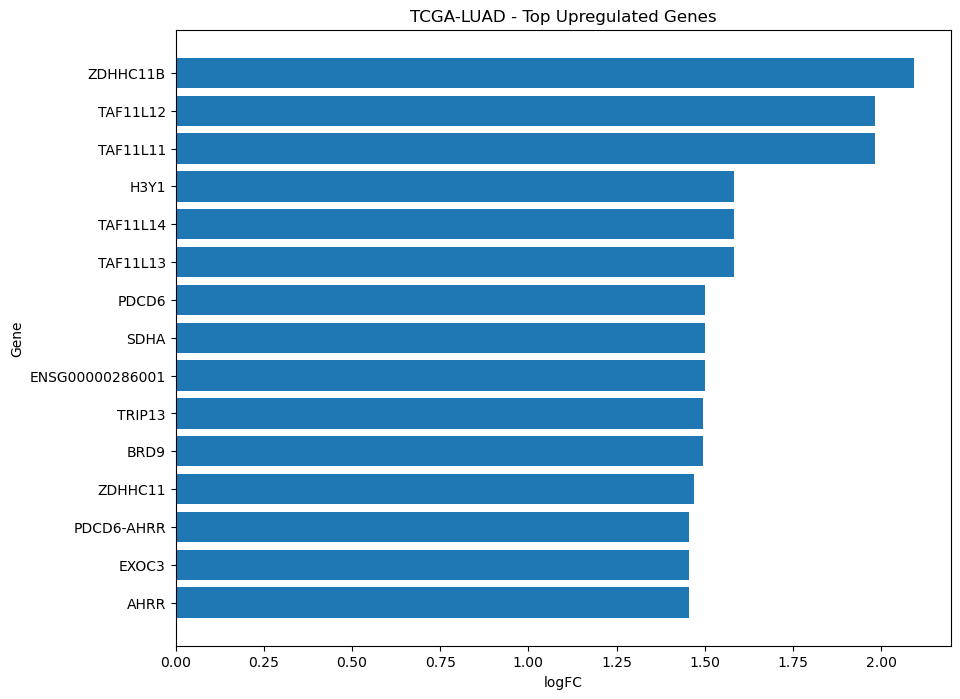

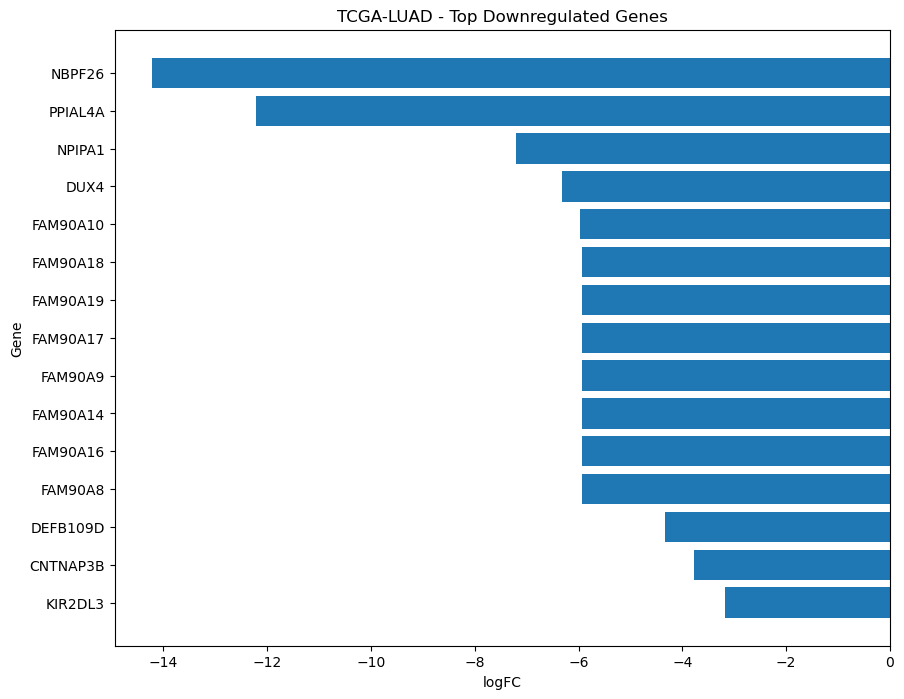


=== TCGA-LUSC ===
[build] CNA matrix: TCGA-LUSC


In [ ]:
def load_cna_matrix(project, gene_annot, gene_list=None):
    cancer_dir = OUT_DIR / project / "cna"

    gene_sample = defaultdict(dict)
    all_samples = set()

    for seg_file in cancer_dir.rglob("*.seg*"):
        try:
            df = pd.read_csv(seg_file, sep="\t")

            # Expected columns
            if not {"Chromosome", "Start", "End", "Segment_Mean"}.issubset(df.columns):
                continue

            sample = seg_file.name.split(".")[0]
            all_samples.add(sample)

            for _, row in df.iterrows():
                chrom = str(row["Chromosome"])
                start = int(row["Start"])
                end = int(row["End"])
                val = float(row["Segment_Mean"])

                # map segment → genes
                for g, (g_chr, g_start, g_end) in gene_annot.items():
                    if chrom == g_chr and not (end < g_start or start > g_end):
                        gene_sample[g][sample] = val

        except Exception as e:
            print(f"[WARN] CNA load failed {seg_file}: {e}")
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    mat = pd.DataFrame(0.0, index=genes, columns=samples)

    for g, sdict in gene_sample.items():
        for s, v in sdict.items():
            mat.at[g, s] = v

    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat

def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    fdr = ranked * n / (np.arange(1, n + 1))
    fdr = np.minimum.accumulate(fdr[::-1])[::-1]

    out = np.empty_like(fdr)
    out[order] = fdr

    return np.clip(out, 0, 1)

from scipy.stats import ttest_1samp

def process_cna(mat, min_samples=10):
    print(f"[DEBUG] CNA matrix: {mat.shape}")

    # filter low signal genes
    gene_counts = (mat != 0).sum(axis=1)
    mat = mat[gene_counts >= min_samples]

    print(f"[DEBUG] After filtering: {mat.shape}")

    # mean CNA signal
    mean_signal = mat.mean(axis=1)

    # t-test vs 0 (neutral copy number)
    pvals = []
    for g in mat.index:
        vals = mat.loc[g].values
        try:
            stat, p = ttest_1samp(vals, 0.0)
        except:
            p = 1.0
        pvals.append(p)

    pval = pd.Series(pvals, index=mat.index)
    fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

    score = mean_signal * (-np.log10(fdr + 1e-10))

    df = pd.DataFrame({
        "gene": mat.index,
        "mean_cna": mean_signal,
        "pval": pval,
        "fdr": fdr,
        "score": score
    }).sort_values("fdr")

    return df

def load_cna_matrix_cached(cancer, gene_annot, gene_list):
    cache_file = OUT_DIR / f"{cancer}_cna_matrix.pkl"

    if cache_file.exists():
        print(f"[cache] CNA matrix: {cancer}")
        return pd.read_pickle(cache_file)

    print(f"[build] CNA matrix: {cancer}")
    mat = load_cna_matrix(cancer, gene_annot, gene_list)

    mat.to_pickle(cache_file)
    return mat


def process_cna_cached(mat, cancer):
    cache_file = OUTPUT_DIR / f"{cancer}_cna_scores.csv"

    if cache_file.exists():
        print(f"[cache] CNA scores: {cancer}")
        return pd.read_csv(cache_file)

    print(f"[compute] CNA scores: {cancer}")
    df = process_cna(mat)

    df.to_csv(cache_file, index=False)
    return df


# ================================
# MAIN
# ================================
gene_list, gene_map, gene_annot = parse_gtf()

cna_dict = {}

for cancer in CANCERS:
    print(f"\n=== {cancer} ===")

    mat = load_cna_matrix_cached(cancer, gene_annot, gene_list)
    df = process_cna_cached(mat, cancer)

    cna_dict[cancer] = df

    # plotting reuse
    df_plot = df.set_index("gene")

    plot_top_genes_combined(df_plot.rename(columns={"score": "logFC"}), cancer)
    plot_top_genes_logfc(df_plot.rename(columns={"score": "logFC"}), cancer)

CNA_all = pd.DataFrame(index=gene_list)
CNA_pval_all = pd.DataFrame(index=gene_list)
CNA_fdr_all = pd.DataFrame(index=gene_list)

for cancer, df in cna_dict.items():
    df = df.set_index("gene")

    CNA_all[cancer] = df["score"]
    CNA_pval_all[cancer] = df["pval"]
    CNA_fdr_all[cancer] = df["fdr"]

mask = (CNA_fdr_all < 0.05).any(axis=1)

CNA_all = CNA_all.loc[mask]
CNA_pval_all = CNA_pval_all.loc[mask]
CNA_fdr_all = CNA_fdr_all.loc[mask]

print(f"[FINAL] Kept {mask.sum()} genes")

CNA_all.to_csv(OUTPUT_DIR / "cna_features.csv")
CNA_pval_all.to_csv(OUTPUT_DIR / "cna_pvalues.csv")
CNA_fdr_all.to_csv(OUTPUT_DIR / "cna_fdr.csv")

print("✅ Saved CNA outputs")



In [ ]:
# from tqdm.auto import tqdm
# import pandas as pd
# import numpy as np
# from collections import defaultdict

# # ================================
# # FDR (same as before)
# # ================================
# def fdr_bh(pvals):
#     pvals = np.asarray(pvals)
#     n = len(pvals)

#     order = np.argsort(pvals)
#     ranked = pvals[order]

#     fdr = ranked * n / (np.arange(1, n + 1))
#     fdr = np.minimum.accumulate(fdr[::-1])[::-1]

#     out = np.empty_like(fdr)
#     out[order] = fdr

#     return np.clip(out, 0, 1)


# # ================================
# # Load mutation data → binary matrix
# # ================================
# def load_mutation_matrix(project, gene_list=None):
#     cancer_dir = DATA_DIR / project

#     gene_sample = defaultdict(set)
#     all_samples = set()

#     for maf_file in cancer_dir.rglob("*.maf*"):
#         try:
#             df = pd.read_csv(
#                 maf_file,
#                 sep="\t",
#                 comment="#",
#                 usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"]
#             ).dropna()

#             for g, s in zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]):
#                 gene_sample[g].add(s)
#                 all_samples.add(s)

#         except:
#             continue

#     genes = list(gene_sample.keys())
#     samples = list(all_samples)

#     mat = pd.DataFrame(0, index=genes, columns=samples)

#     for g, ss in gene_sample.items():
#         mat.loc[g, list(ss)] = 1

#     if gene_list is not None:
#         mat = mat.reindex(gene_list).fillna(0)

#     return mat


# # ================================
# # Mutation "differential" scoring
# # ================================
# def process_mutation(mat, min_samples=10):
#     print(f"[DEBUG] Mutation matrix: {mat.shape}")

#     # remove rare genes
#     gene_counts = mat.sum(axis=1)
#     mat = mat[gene_counts >= min_samples]

#     print(f"[DEBUG] After filtering: {mat.shape}")

#     # mutation frequency
#     freq = mat.mean(axis=1)

#     # binomial test vs background
#     background = freq.mean()

#     pvals = []
#     for g in mat.index:
#         k = int(mat.loc[g].sum())
#         n = mat.shape[1]

#         # simple enrichment test
#         p = binomtest(k, n, background, alternative="greater").pvalue
#         pvals.append(p)

#     pval = pd.Series(pvals, index=mat.index)
#     fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

#     score = freq * (-np.log10(fdr + 1e-10))

#     df = pd.DataFrame({
#         "gene": mat.index,
#         "freq": freq,
#         "pval": pval,
#         "fdr": fdr,
#         "score": score
#     }).sort_values("fdr")

#     return df


# def load_mutation_matrix_cached(cancer, gene_list):
#     cache_file = OUT_DIR / f"{cancer}_mutation_matrix.pkl"

#     if cache_file.exists():
#         print(f"[cache] mutation matrix: {cancer}")
#         return pd.read_pickle(cache_file)

#     print(f"[build] mutation matrix: {cancer}")
#     mat = load_mutation_matrix(cancer, gene_list)

#     mat.to_pickle(cache_file)
#     return mat



# def process_mutation_cached(mat, cancer):
#     cache_file = OUTPUT_DIR / f"{cancer}_mutation_scores.csv"

#     if cache_file.exists():
#         print(f"[cache] mutation scores: {cancer}")
#         return pd.read_csv(cache_file)

#     print(f"[compute] mutation scores: {cancer}")
#     df = process_mutation(mat)

#     df.to_csv(cache_file, index=False)
#     return df



# # ================================
# # MAIN
# # ================================
# gene_list, gene_map, gene_annot = parse_gtf()

# mutation_dict = {}

# for cancer in CANCERS:
#     print(f"\n=== {cancer} ===")

#     file_ids = get_maf_file_ids(cancer)
#     download_maf_files(file_ids, cancer)

#     # mat = load_mutation_matrix(cancer, gene_list)

#     # df = process_mutation(mat)

#     mat = load_mutation_matrix_cached(cancer, gene_list)
#     df = process_mutation_cached(mat, cancer)

#     mutation_dict[cancer] = df

#     # plotting
#     df_plot = df.set_index("gene")

#     plot_top_genes_combined(df_plot.rename(columns={"score": "logFC"}), cancer)
#     plot_top_genes_logfc(df_plot.rename(columns={"score": "logFC"}), cancer)


# # ================================
# # Aggregate
# # ================================
# MF_all = pd.DataFrame(index=gene_list)
# MF_pval_all = pd.DataFrame(index=gene_list)
# MF_fdr_all = pd.DataFrame(index=gene_list)

# for cancer, df in mutation_dict.items():
#     df = df.set_index("gene")

#     MF_all[cancer] = df["score"]
#     MF_pval_all[cancer] = df["pval"]
#     MF_fdr_all[cancer] = df["fdr"]


# # ================================
# # Filtering
# # ================================
# mask = (MF_fdr_all < 0.05).any(axis=1)

# MF_all = MF_all.loc[mask]
# MF_pval_all = MF_pval_all.loc[mask]
# MF_fdr_all = MF_fdr_all.loc[mask]

# print(f"[FINAL] Kept {mask.sum()} genes")


# # ================================
# # Save
# # ================================
# MF_all.to_csv(OUTPUT_DIR / "mutation_features.csv")
# MF_pval_all.to_csv(OUTPUT_DIR / "mutation_pvalues.csv")
# MF_fdr_all.to_csv(OUTPUT_DIR / "mutation_fdr.csv")

# print("✅ Saved mutation outputs")